In [5]:
import os, sys, pickle
import numpy as np
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
from torchinfo import summary
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import albumentations as A
from pathlib import Path
import wandb
from tqdm import tqdm
sns.set()
api = wandb.Api()

sys.path.append(os.path.abspath("."))
from src_vae.train import train_vae
from src_vae.model import VAEModel
from src_vae.data import ZiramF0Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

import datetime

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Using device: cuda


In [ ]:
X_train = ZiramF0Dataset(img_type="full_dataset", train=True, val=False, test=False, apply_transform=False)
X_val = ZiramF0Dataset(img_type="full_dataset", train=False, val=True, test=False, apply_transform=False)

# Load all images
loader_train = DataLoader(X_train, batch_size=X_train.__len__(), shuffle=False, num_workers=1, pin_memory=True)
train_all = next(iter(loader_train))
loader_val = DataLoader(X_val, batch_size=X_val.__len__(), shuffle=False, num_workers=1, pin_memory=True)
val_all = next(iter(loader_val))

In [19]:
sweep_dir = f"/nfs/research/birney/users/esther/medaka-ziram/results/sweep_{sweep_id}"

In [ ]:
run_dirs = [p.name for p in Path(sweep_dir).iterdir() if p.is_dir()]

In [22]:
len(run_dirs)

97

In [21]:
run_dirs

['20260629-2148_expert-sweep-99',
 '20260629-1758_blooming-sweep-59',
 '20260629-1832_robust-sweep-63',
 '20260629-1602_sunny-sweep-35',
 '20260629-1946_giddy-sweep-73',
 '20260629-1834_ancient-sweep-64',
 '20260629-1608_warm-sweep-37',
 '20260629-1628_worldly-sweep-39',
 '20260629-1523_lunar-sweep-29',
 '20260629-2131_likely-sweep-96',
 '20260629-1732_giddy-sweep-52',
 '20260629-1802_golden-sweep-60',
 '20260629-2039_smooth-sweep-85',
 '20260629-1435_desert-sweep-23',
 '20260629-1517_laced-sweep-28',
 '20260629-1844_resilient-sweep-65',
 '20260629-1705_light-sweep-47',
 '20260629-2012_sleek-sweep-80',
 '20260629-1758_still-sweep-58',
 '20260629-1318_smooth-sweep-11',
 '20260629-2051_fine-sweep-90',
 '20260629-1529_swift-sweep-30',
 '20260629-1901_wild-sweep-67',
 '20260629-1818_winter-sweep-62',
 '20260629-1301_worthy-sweep-4',
 '20260629-2101_young-sweep-91',
 '20260629-1405_magic-sweep-20',
 '20260629-1503_vibrant-sweep-25',
 '20260629-1309_lively-sweep-9',
 '20260629-2045_devoted-s

### Load pretrained

In [6]:
model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/sweep_0a39n1bn/20260629-1832_robust-sweep-63/"

# Get parameters via wandb
sweep_id = "0a39n1bn"

runs_map_df = pd.read_csv(f"/nfs/research/birney/users/esther/medaka-ziram/results/sweep_{sweep_id}/runs_name_to_id.csv")
runs_map_dict = dict(zip(runs_map_df["run_name"], runs_map_df["run_id"]))

run_name = os.path.basename(model_dir[:-1]).split("_", 1)[1]
run_id = runs_map_dict[run_name]
run = api.run(f"ey267-university-of-cambridge/Ziram VAE Training/{sweep_id}/{run_id}")

model = VAEModel(
    input_dim=X_train[0][0].shape,
    latent_dim=run.config['latent_dim'],
    capacity=run.config['capacity'],
    depth=run.config['depth'],
    kld_b=run.config['kld_b'],
    batch_size=run.config['batch_size'],
    dropout_p=run.config['dropout_p'],
    device=device
)

model_ckpt = torch.load(model_dir + "model.pt")
model.load_state_dict(model_ckpt,
                      strict=False)
model.eval()

input_dim:  torch.Size([1, 352, 352])
latent_dim:  256
capacity:  32
depth:  5
batch_size:  16
dropout:  0.2


/tmp/ipykernel_2819477/881960701.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(model_dir + "model.pt")


VAEModel(
  (vae): VAE(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Identity()
      )
      (1): Sequential(
        (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Identity()
      )
      (2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Identity()
      )
      (3): Sequential(
        (0): Conv2d(128, 256, kernel_size=(4, 4), strid

### View reconstruction

In [12]:
sample[0].shape

torch.Size([1, 352, 352])

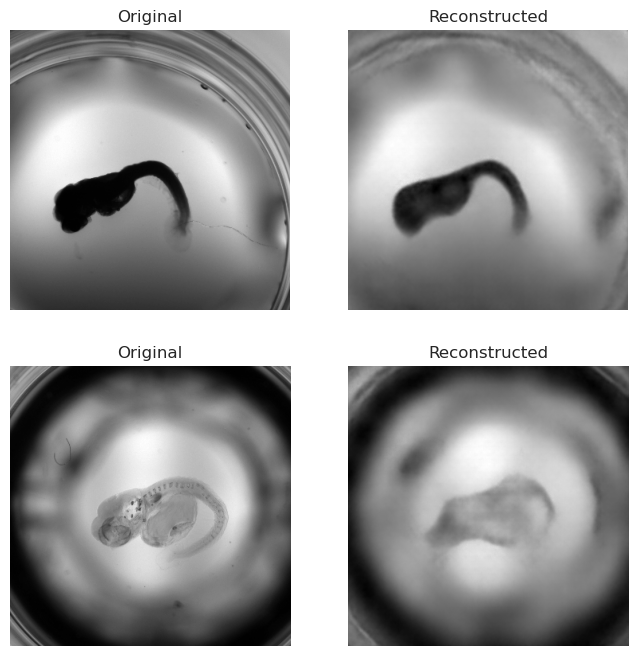

In [17]:
idx = 0 # Sample index to reconstruct

sample = X_val[idx]
recon = model.vae(sample[0].unsqueeze(0).to(device))

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs[0, 0].imshow(sample[0].squeeze(0).cpu().detach(), cmap='gray')
axs[0, 0].set_title('Original')
axs[0, 0].axis('off')
axs[0, 1].imshow(recon[0].squeeze(0).squeeze(0).cpu().detach(), cmap='gray')
axs[0, 1].set_title('Reconstructed')
axs[0, 1].axis('off')

idx = 60 # Sample index to reconstruct
sample = X_val[idx]
recon = model.vae(sample[0].unsqueeze(0).to(device))

axs[1, 0].imshow(sample[0].squeeze(0).cpu().detach(), cmap='gray')
axs[1, 0].set_title('Original')
axs[1, 0].axis('off')
axs[1, 1].imshow(recon[0].squeeze(0).squeeze(0).cpu().detach(), cmap='gray')
axs[1, 1].set_title('Reconstructed')
axs[1, 1].axis('off')
plt.savefig(f"{model_dir}/validation_reconstruction.png", dpi=300, bbox_inches='tight')
plt.show()

### Get VAE latents

In [80]:
# Get latent mean, logvar for each sample
train_all_means, train_all_logvars = model.vae.get_latent(
    train_all[0].to(device)
)
val_all_means, val_all_logvars = model.vae.get_latent(
    val_all[0].to(device)
)
train_all_means = train_all_means.detach().cpu().numpy()
train_all_logvars = train_all_logvars.detach().cpu().numpy()
val_all_means = val_all_means.detach().cpu().numpy()
val_all_logvars = val_all_logvars.detach().cpu().numpy()

In [19]:
CLFS = [('LogReg', LogisticRegression(max_iter=3000)),
        ('RF', RandomForestClassifier(n_estimators=300, random_state=0))]

def report(X, y, name):
    """Run the protocol; print and RETURN (metric rows, confusion matrices)."""
    X = StandardScaler().fit_transform(np.asarray(X, dtype=float))
    y = np.asarray(y).astype(int)
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    n, dims = len(y), X.shape[1]
    rows, cms = [], {}
    print(f"\n=== {name}  (n={n}, dims={dims}, classes={np.bincount(y).tolist()}) ===")
    print("  5-class (severity SC0-4):")
    for nm, clf in CLFS:
        yp = cross_val_predict(clf, X, y, cv=cv)
        r = dict(method=name, task='5class', classifier=nm, n=n, dims=dims,
                 acc=accuracy_score(y, yp), macroF1=f1_score(y, yp, average='macro'),
                 weightedF1=f1_score(y, yp, average='weighted'),
                 quadKappa=cohen_kappa_score(y, yp, weights='quadratic'))
        rows.append(r); cms[f'5class_{nm}'] = confusion_matrix(y, yp)
        print(f"    {nm:7s} acc={r['acc']:.3f} macroF1={r['macroF1']:.3f} "
              f"weightedF1={r['weightedF1']:.3f} quadKappa={r['quadKappa']:.3f}")
    yb = (y > 0).astype(int)
    print("  binary (SC0 vs any-kink):")
    for nm, clf in CLFS:
        yp = cross_val_predict(clf, X, yb, cv=cv)
        r = dict(method=name, task='binary', classifier=nm, n=n, dims=dims,
                 acc=accuracy_score(yb, yp), macroF1=f1_score(yb, yp, average='macro'),
                 weightedF1=f1_score(yb, yp, average='weighted'),
                 quadKappa=cohen_kappa_score(yb, yp))   # binary: unweighted kappa
        rows.append(r); cms[f'binary_{nm}'] = confusion_matrix(yb, yp)
        print(f"    {nm:7s} acc={r['acc']:.3f} F1(affected)={f1_score(yb,yp):.3f} "
              f"macroF1={r['macroF1']:.3f} kappa={r['quadKappa']:.3f}")
    return rows, cms


=== 20260629-1832_robust-sweep-63  (n=577, dims=256, classes=[107, 107, 124, 119, 120]) ===
  5-class (severity SC0-4):
    LogReg  acc=0.213 macroF1=0.213 weightedF1=0.214 quadKappa=0.036
    RF      acc=0.227 macroF1=0.220 weightedF1=0.222 quadKappa=0.075
  binary (SC0 vs any-kink):
    LogReg  acc=0.709 F1(affected)=0.819 macroF1=0.538 kappa=0.076
    RF      acc=0.815 F1(affected)=0.898 macroF1=0.449 kappa=0.000

[OK] saved metrics_20260629-1832_robust-sweep-63.csv (+ confusion matrices) -> /nfs/research/birney/users/esther/medaka-ziram/results/sweep_0a39n1bn/20260629-1832_robust-sweep-63//
[OK] master comparison table -> /nfs/research/birney/users/esther/medaka-ziram/results/sweep_0a39n1bn/20260629-1832_robust-sweep-63/all_methods_comparison.csv


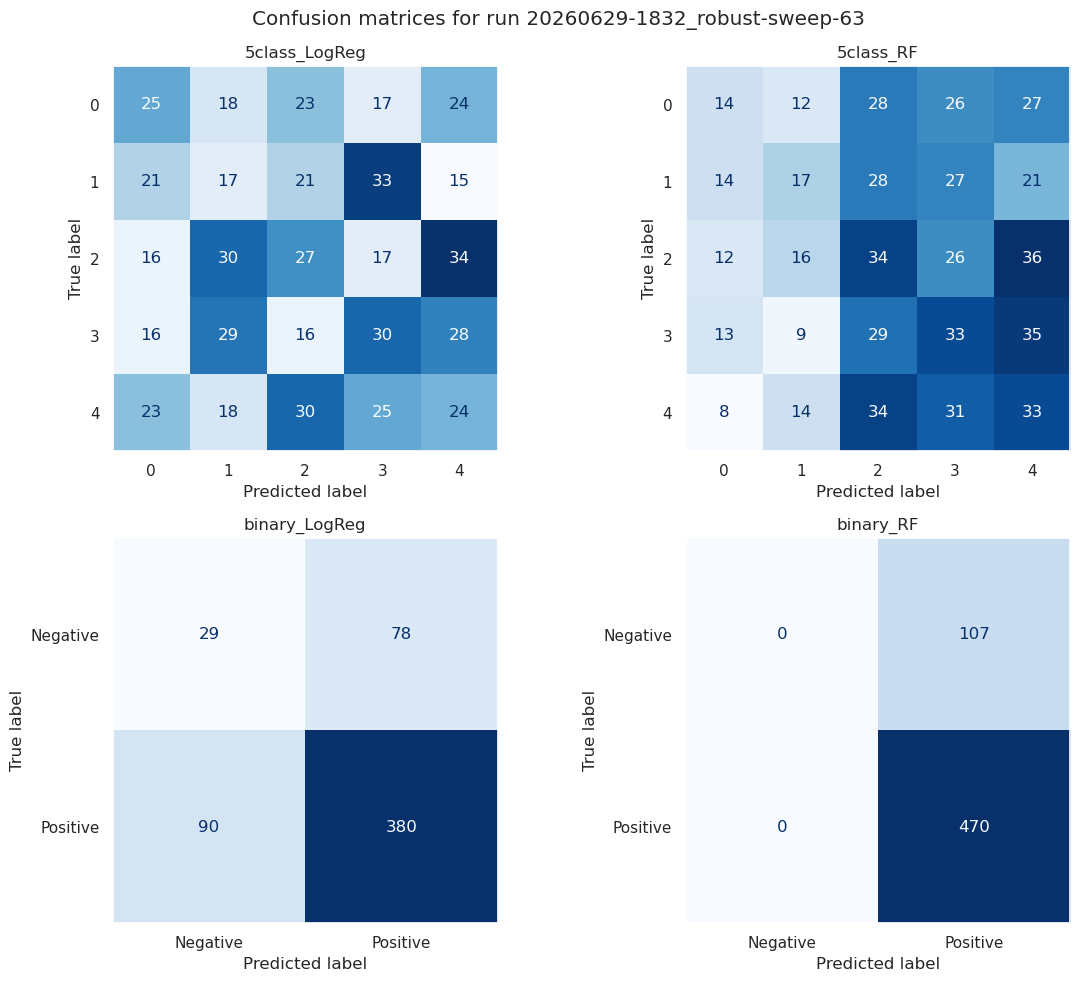

In [81]:
### Run standard evaluation
std_eval_name = os.path.basename(model_dir[:-1])

rows, cms = report(X = train_all_means, 
                   y = train_all[5]['severity_score_adjusted'].detach().cpu().numpy(),
                   name = std_eval_name)

# --- save: per-run metrics, confusion matrices, and append to a master table ---
output_dir = model_dir
safe = ''.join(c if c.isalnum() or c in '-_' else '_' for c in std_eval_name)
run_df = pd.DataFrame(rows)
run_df.to_csv(os.path.join(output_dir, f'metrics_{safe}.csv'), index=False)
for k, cm in cms.items():
    np.savetxt(os.path.join(output_dir, f'confusion_{safe}_{k}.csv'), cm, fmt='%d', delimiter=',')
master = os.path.join(output_dir, 'all_methods_comparison.csv')
prev = pd.read_csv(master) if os.path.exists(master) else pd.DataFrame()
if len(prev):   # re-running a name overwrites its old rows
    key = ['method', 'task', 'classifier']
    prev = prev[~prev[key].apply(tuple, 1).isin(run_df[key].apply(tuple, 1))]
pd.concat([prev, run_df], ignore_index=True).to_csv(master, index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

### Save confusion matrix
for ax, (name, cm) in zip(axes, cms.items()):
    # Choose labels based on matrix size
    if cm.shape[0] == 2:
        labels = ["Negative", "Positive"]
    else:
        labels = [str(i) for i in range(cm.shape[0])]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)

fig.suptitle(f"Confusion matrices for run {std_eval_name}")
plt.tight_layout()
plt.savefig(f"{output_dir}/cm.png", dpi=300, bbox_inches='tight')

print(f"\n[OK] saved metrics_{safe}.csv (+ confusion matrices) -> {output_dir}/")
print(f"[OK] master comparison table -> {master}")

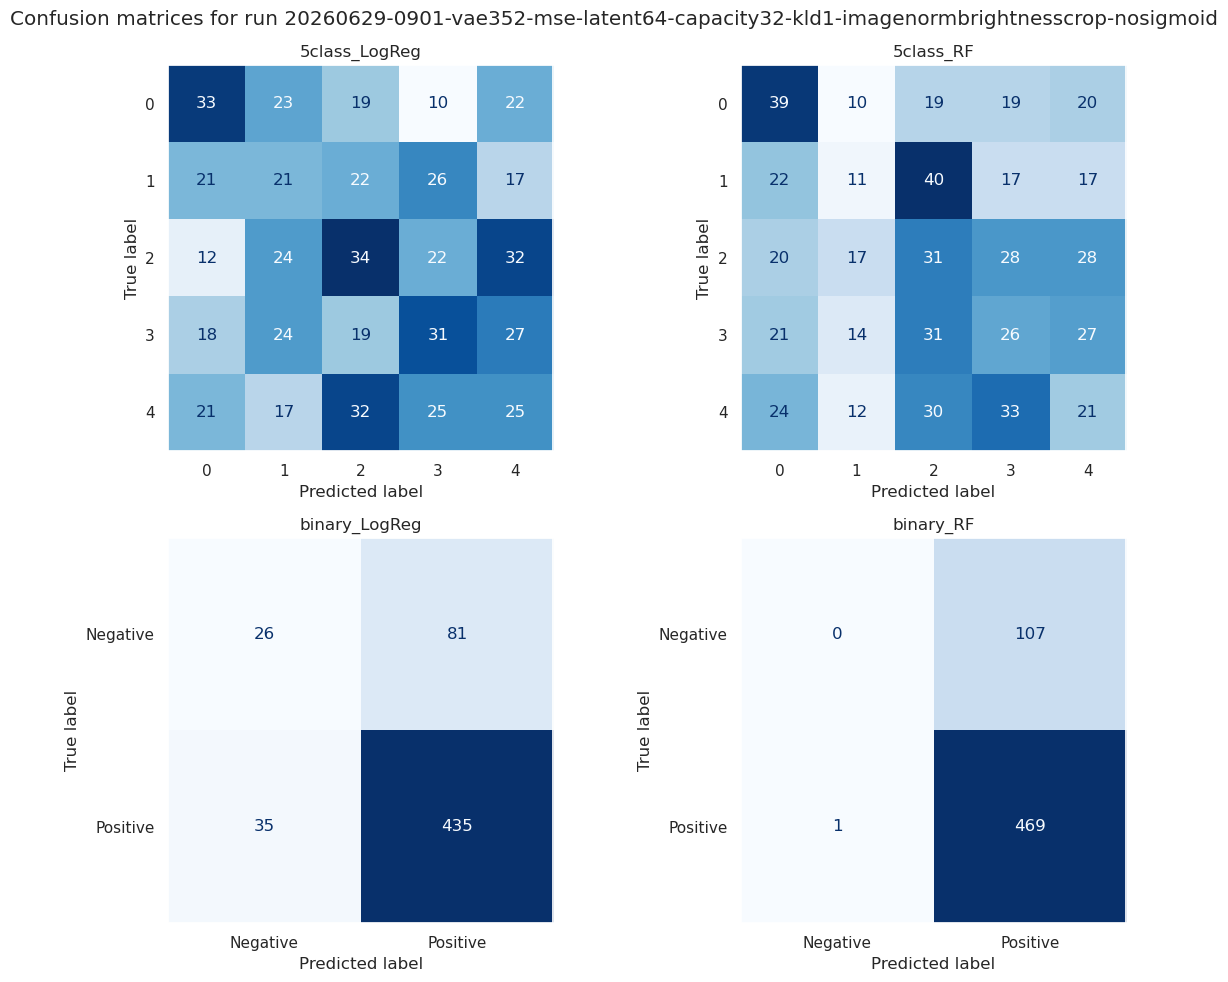

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, cm) in zip(axes, cms.items()):
    # Choose labels based on matrix size
    if cm.shape[0] == 2:
        labels = ["Negative", "Positive"]
    else:
        labels = [str(i) for i in range(cm.shape[0])]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)

fig.suptitle(f"Confusion matrices for run {std_eval_name}")
plt.tight_layout()
plt.show()